In [ ]:
#Task 4 - Data Visualization and Analysis - all analysis is done using the clean dataset
import pandas as pd
df = pd.read_csv("medical_insurance_cleaned.csv")
#Key categories to analyze: risk score vs controllable variables
#such as bmi, income, smoker, alcohol_freq, urban_rural and how they affect risk score
# by understanding the relationships, we may be able to identify areas for intervention to reduce risk score and improve patient outcomes.

In [10]:
#Begin with numerical summaries of the data to get a sense of the distribution of the variables
num_features = ["bmi", "income", "risk_score"]
categorical_features = ["smoker", "alcohol_freq", "urban_rural"]
print("Summary statistics for the numerical variables in the dataset:")
print(df[num_features].describe())

Summary statistics for the numerical variables in the dataset:
                 bmi        income     risk_score
count  100000.000000  1.000000e+05  100000.000000
mean       26.990512  4.987390e+04       0.519849
std         4.994883  4.680021e+04       0.250669
min        12.000000  1.100000e+03       0.000000
25%        23.600000  2.110000e+04       0.329700
50%        27.000000  3.620000e+04       0.505500
75%        30.400000  6.220000e+04       0.703300
max        50.400000  1.061800e+06       1.000000


In [ ]:
skew_results = df[num_features].skew().round(2)
print(skew_results)

#then we can visualize the relationships between the risk score and the controllable variables using scatter plots for numerical variables and box plots for categorical variables. This will help us identify any patterns or trends in the data that may be useful for intervention strategies.

bmi       0.02
income    3.39
dtype: float64


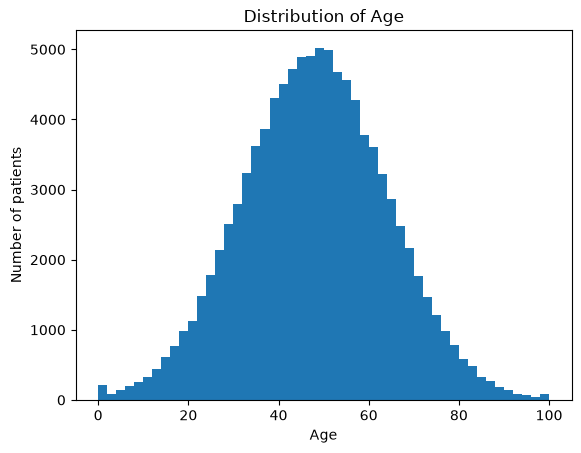

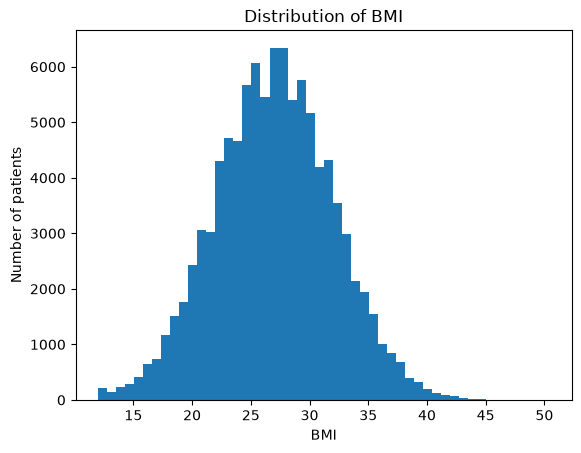

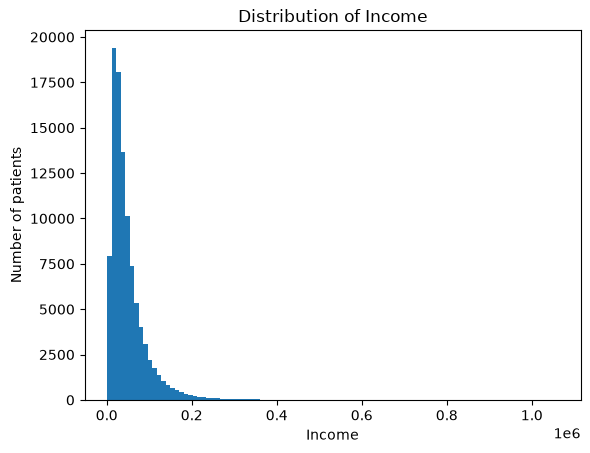

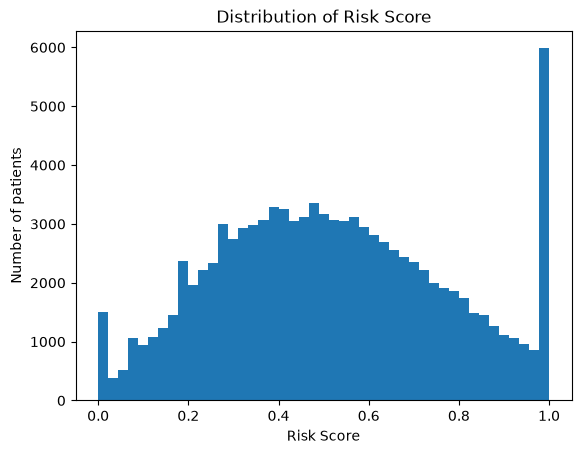

In [7]:
#Histograms of the numerical variables to visualize the distribution of the data
import matplotlib.pyplot as plt

plt.hist(df["age"].dropna(), bins=50)
plt.xlabel("Age"); plt.ylabel("Number of patients")
plt.title("Distribution of Age")
plt.show()

plt.hist(df["bmi"].dropna(), bins=50)
plt.xlabel("BMI"); plt.ylabel("Number of patients")
plt.title("Distribution of BMI")
plt.show()

plt.hist(df["income"].dropna(), bins=100)
plt.xlabel("Income"); plt.ylabel("Number of patients")
plt.title("Distribution of Income")
plt.show()

plt.hist(df["risk_score"].dropna(), bins=45)
plt.xlabel("Risk Score"); plt.ylabel("Number of patients")
plt.title("Distribution of Risk Score")
plt.show()


#from the histograms, we can see that age is roughly normally distributed, with a slight skew to the right. BMI is also roughly normally distributed, with a slight skew to the right. Risk score is heavily skewed to the right, with most patients having a low risk score and a few outliers having a high risk score. Chronic count is also heavily skewed to the right, with most patients having a low number of chronic conditions and a few outliers having a high number of chronic conditions.

In [8]:
#How many patients have a risk score of 0, and how many have a risk score of 1 or higher
print(df[df["risk_score"] == 0].shape[0])   
print(df[df["risk_score"] >= 1].shape[0])

#1131 patients have a risk score of 0, and 5241 patients have a risk score of 1 or higher.

1131
5241


C:\Users\ivorc\AppData\Local\Temp\ipykernel_12376\1262261344.py:10: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['smoker'] = pd.Categorical(df['smoker'], categories=['never', 'former', 'current'], ordered=True)
C:\Users\ivorc\AppData\Local\Temp\ipykernel_12376\1262261344.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['alcohol_freq'] = pd.Categorical(df['alcohol_freq'], categories=['none', 'occasionally', 'weekly', 'daily'], ordered=True)
C:\Users\ivorc\AppData\Local\Temp\ipykernel_12376\1262261344.py:12: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['urban_rural'] = pd.Categorical(


=== RISK SCORE BY URBAN_RURAL ===
             Count  Mean  Std  Median  IQR
urban_rural                               
rural            0   NaN  NaN     NaN  NaN
suburban         0   NaN  NaN     NaN  NaN
urban            0   NaN  NaN     NaN  NaN

=== RISK SCORE BY SMOKER ===
         Count  Mean  Std  Median  IQR
smoker                                
never        0   NaN  NaN     NaN  NaN
former       0   NaN  NaN     NaN  NaN
current      0   NaN  NaN     NaN  NaN

=== RISK SCORE BY ALCOHOL_FREQ ===
              Count  Mean  Std  Median  IQR
alcohol_freq                               
none              0   NaN  NaN     NaN  NaN
occasionally      0   NaN  NaN     NaN  NaN
weekly            0   NaN  NaN     NaN  NaN
daily             0   NaN  NaN     NaN  NaN


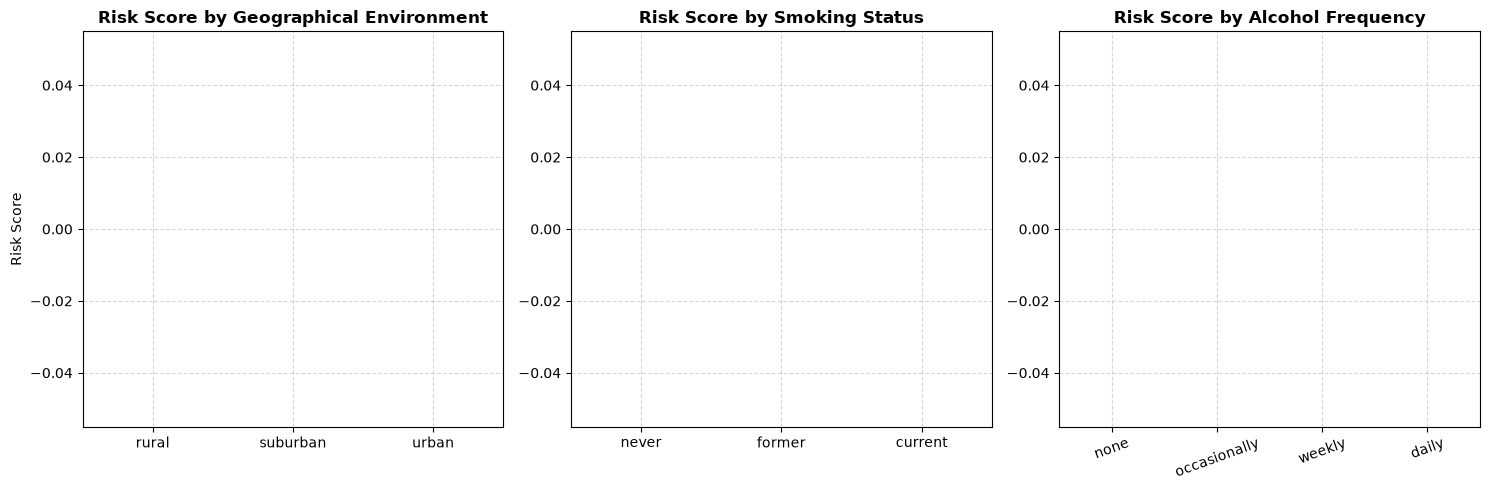

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load Dataset
df = pd.read_csv('medical_insurance_cleaned.csv')

# Convert categories to ordered factors if applicable
df['smoker'] = pd.Categorical(df['smoker'], categories=['never', 'former', 'current'], ordered=True)
df['alcohol_freq'] = pd.Categorical(df['alcohol_freq'], categories=['none', 'occasionally', 'weekly', 'daily'], ordered=True)
df['urban_rural'] = pd.Categorical(df['urban_rural'], categories=['rural', 'suburban', 'urban'], ordered=True)

# -----------------------------------------------------------------------------
# STEP 1: SUMMARY STATISTICS (Print for Report Tables)
# -----------------------------------------------------------------------------
for col in ['urban_rural', 'smoker', 'alcohol_freq']:
    print(f"\n=== RISK SCORE BY {col.upper()} ===")
    summary = df.groupby(col, observed=False)['risk_score'].agg(
        Count='count', Mean='mean', Std='std', Median='median',
        IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    print(summary)

# -----------------------------------------------------------------------------
# STEP 2: BIVARIATE BOXPLOTS (Individual Factors vs. Risk Score)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = ['urban_rural', 'smoker', 'alcohol_freq']
titles = ['Geographical Environment', 'Smoking Status', 'Alcohol Frequency']

for i, col in enumerate(cols):
    groups = df.groupby(col, observed=False)['risk_score']
    labels = [str(name) for name, _ in groups]
    data = [group.dropna().values for _, group in groups]
    
    axes[i].boxplot(data, tick_labels=labels, showmeans=True)
    axes[i].set_title(f'Risk Score by {titles[i]}', fontweight='bold')
    axes[i].set_ylabel('Risk Score' if i == 0 else '')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    if col == 'alcohol_freq':
        axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()